# Testing mandelbrot-calculator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from dataclasses import dataclass

from mandelbrot_calculator import (
    is_in_mandelbrot_set,
    MandelbrotSet,
)

Testing the function that determines whether a point is in the Mandelbrot set.

In [2]:
is_in_mandelbrot_set(0, 0.5, 100)

True

Testing the class that allows the user to set up an instance of the `MandelbrotSet` class, with a chosen grid size and max number of iterations.

In [3]:
ms = MandelbrotSet(5000, 250)

Calculating a grid for given min/max of the real an imaginary part of the points to be checked.

In [4]:
re_min, re_max, im_min, im_max = -1, 1, -1, 1

grid = ms.make_grid(re_min, re_max, im_min, im_max)

Plotting the result (what do you know, it looks how i would've hoped)

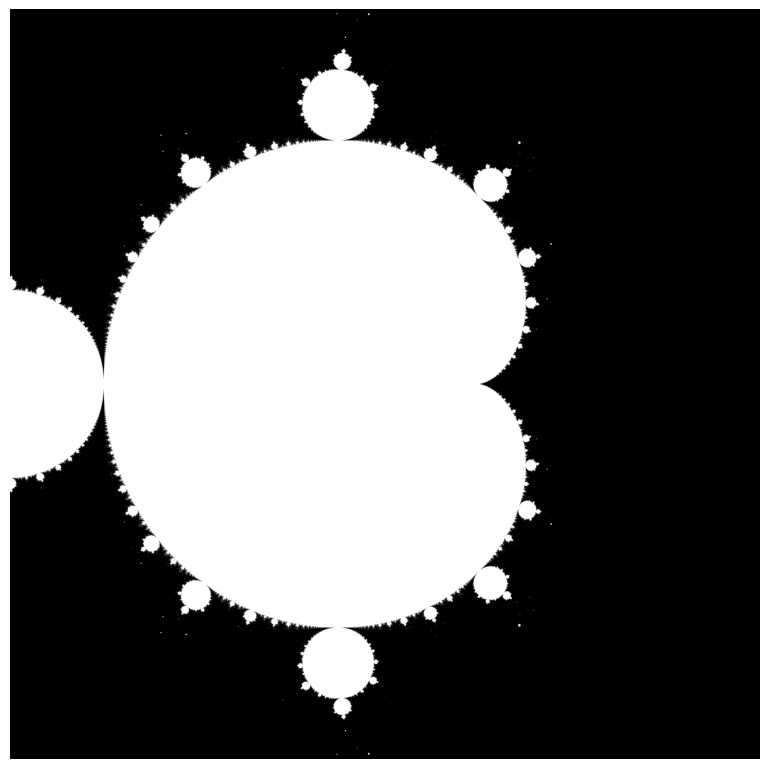

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(grid, extent=(re_min, re_max, im_min, im_max), cmap='gray')
ax.set_xticks(np.linspace(re_min, re_max, 5))
ax.set_yticks(np.linspace(im_min, im_max, 5))
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

## Iterative zoom WIP

Since the Mandelbrot is a fractal (the pattern repeats itself as you zoom in), it's worthwhile to make an iterative plot where I zoom into some point. Hence, I do it:

In [6]:
ms = MandelbrotSet(2000, 2000)

In [7]:
@dataclass
class Range:
    re_min: float
    re_max: float
    im_min: float
    im_max: float

def add_plot_to_ax(ax: plt.Axes, range: Range, new_range: Range) -> None:
    grid = ms.make_grid(range.re_min, range.re_max, range.im_min, range.im_max)
    ax.imshow(grid, extent=(range.re_min, range.re_max, range.im_min, range.im_max), cmap='gray')
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout(pad=0)

    rect = Rectangle(
        (new_range.re_min,new_range.im_min),
        new_range.re_max-new_range.re_min,
        new_range.im_max-new_range.im_min,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

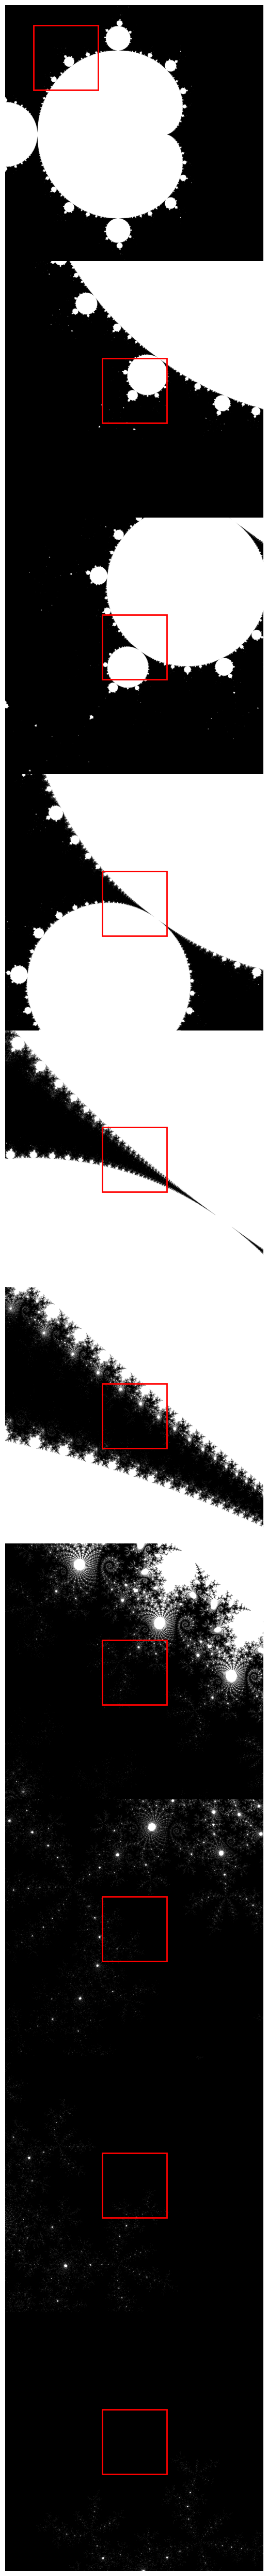

In [8]:
fig, axs = plt.subplots(nrows=10, figsize=(5, 50))

range = Range(-1, 1, -1, 1)
new_range = Range(-0.78, -0.78+0.5, 0.3425, 0.3425+0.5)

add_plot_to_ax(axs[0], range, new_range)

for ax in axs[1:]:
    range = Range(**new_range.__dict__)
    new_range = Range(
        (range.re_min + range.re_max)/2 - (range.re_max - range.re_min)/8,
        (range.re_min + range.re_max)/2 + (range.re_max - range.re_min)/8,
        (range.im_min + range.im_max)/2 - (range.im_max - range.im_min)/8,
        (range.im_min + range.im_max)/2 + (range.im_max - range.im_min)/8
    )
    add_plot_to_ax(ax, range, new_range)

plt.show()